[[[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 ...

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]]


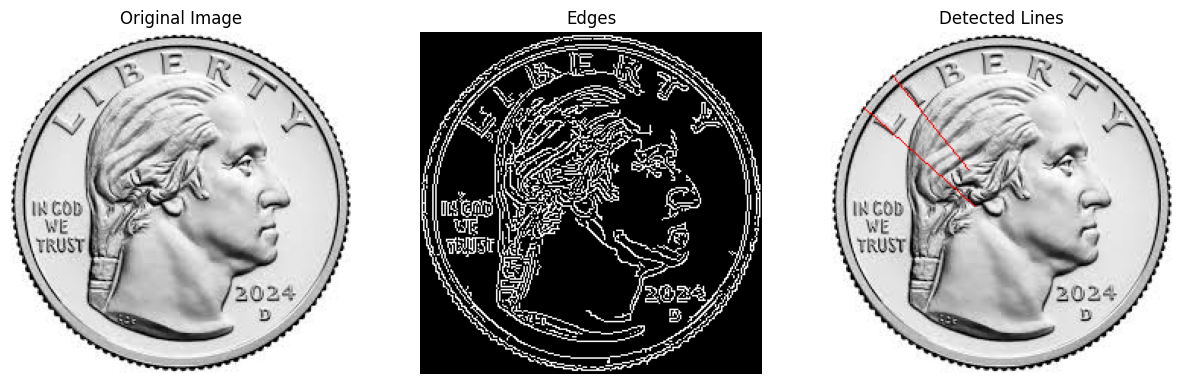

[[[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 ...

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]]


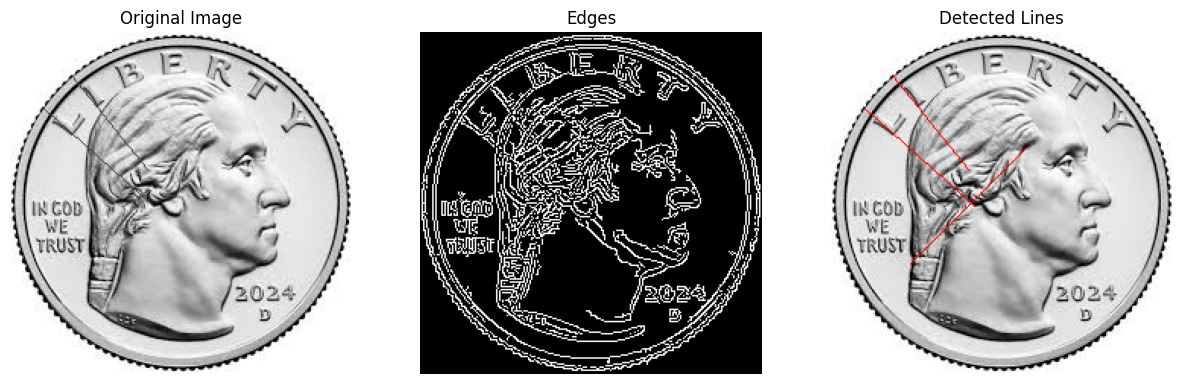

In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load the image
# Check if the image path is correct and the image file exists
image_path = "/content/image.jpeg"
img = cv2.imread(image_path)

# Print img to check its value, will be None if image not loaded
print(img)

# Check if image loading was successful
if img is None:
    print(f"Error: Could not load image from {image_path}. Please check the file path and ensure the image exists.")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply Canny edge detection
    edges = cv2.Canny(gray, 40, 200)

    # Detect lines using Hough Transform
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, 50, minLineLength=60, maxLineGap=4)

    # Draw detected lines on the image
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            cv2.line(img, (x1, y1), (x2, y2), (0, 0, 255), 1)

    # Display results
    plt.figure(figsize=(15, 10))

    plt.subplot(131)
    plt.axis('off')
    plt.title('Original Image')
    plt.imshow(gray, cmap='gray')

    plt.subplot(132)
    plt.imshow(edges, cmap='gray')
    plt.axis('off')
    plt.title('Edges')

    plt.subplot(133)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Detected Lines')

    plt.show()
# Print img to check its value, will be None if image not loaded
print(img)

# Check if image loading was successful
if img is None:
    print(f"Error: Could not load image from {image_path}. Please check the file path and ensure the image exists.")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply Canny edge detection
    edges = cv2.Canny(gray, 40, 200)

    # Detect lines using Hough Transform
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, 50, minLineLength=60, maxLineGap=4)

    # Draw detected lines on the image
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            cv2.line(img, (x1, y1), (x2, y2), (0, 0, 255), 1)

    # Display results
    plt.figure(figsize=(15, 10))

    plt.subplot(131)
    plt.axis('off')
    plt.title('Original Image')
    plt.imshow(gray, cmap='gray')

    plt.subplot(132)
    plt.imshow(edges, cmap='gray')
    plt.axis('off')
    plt.title('Edges')

    plt.subplot(133)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Detected Lines')

    plt.show()

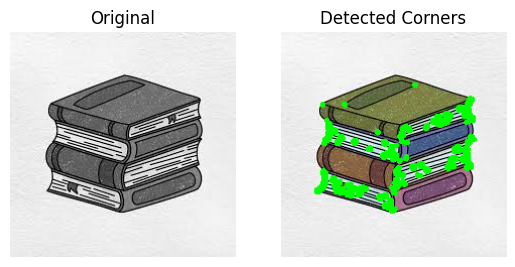

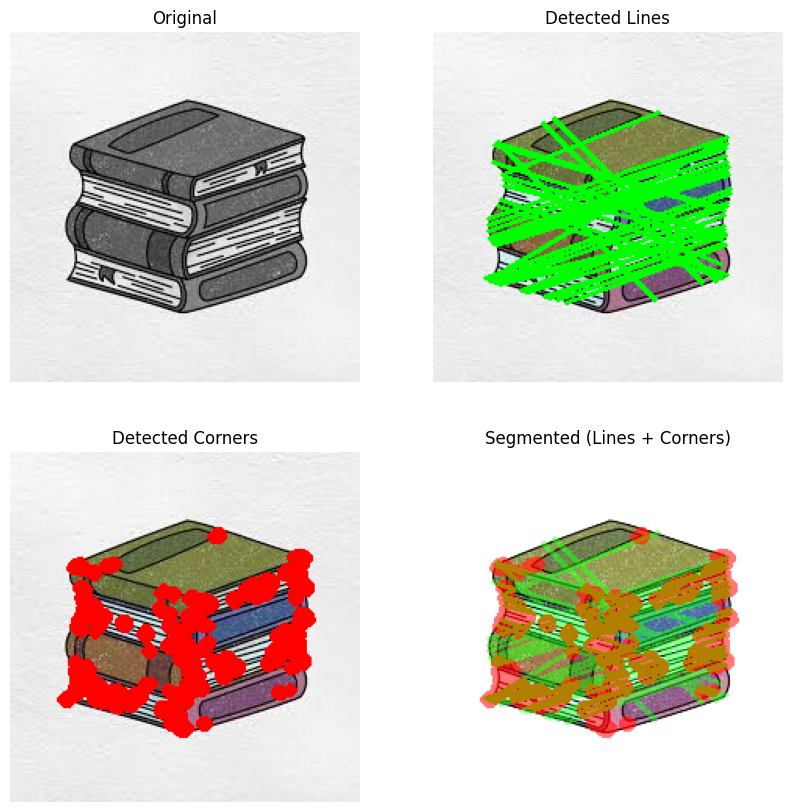

In [14]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load the image
image_copy = cv2.imread("/content/book.jpeg")
gray = cv2.cvtColor(image_copy, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)

# Apply Harris Corner Detection
dst = cv2.cornerHarris(gray, 3, 5, 0.06)
dst = cv2.dilate(dst, None)

# Set threshold for detecting corners
thresh = 0.02 * dst.max()
corner_image = np.copy(image_copy)

# Draw corners
for j in range(dst.shape[0]):
    for i in range(dst.shape[1]):
        if dst[j, i] > thresh:
            cv2.circle(corner_image, (i, j), 1, (0, 255, 0), 1)

# Display results
plt.subplot(121)
plt.title('Original')
plt.axis('off')
plt.imshow(gray, cmap='gray')

plt.subplot(122)
plt.title('Detected Corners')
plt.axis('off')
plt.imshow(corner_image)

plt.show()

# Second part of the code
img = cv2.imread(r'/content/book.jpeg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Detect edges
edges = cv2.Canny(gray, 40, 200)

# Detect lines using Hough Transform
lines = cv2.HoughLinesP(edges, 1, np.pi/180, 50, minLineLength=100, maxLineGap=30)

# Draw detected lines on the image
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

# Load another image copy for corner detection
image_copy1 = cv2.imread(r'/content/book.jpeg')
g1 = cv2.cvtColor(image_copy1, cv2.COLOR_BGR2GRAY)
g1 = np.float32(g1)

# Apply Harris Corner Detection
dst1 = cv2.cornerHarris(g1, 3, 5, 0.06)
dst1 = cv2.dilate(dst1, None)

# Set threshold for detecting corners
thresh1 = 0.003 * dst1.max()
corner_image1 = np.copy(image_copy1)

# Draw corners
for j in range(dst1.shape[0]):
    for i in range(dst1.shape[1]):
        if dst1[j, i] > thresh1:
            cv2.circle(corner_image1, (i, j), 1, (255, 0, 0), 3)

# Display results
plt.figure(figsize=(10, 10))

plt.subplot(221)
plt.axis('off')
plt.title('Original')
plt.imshow(gray, cmap='gray')

plt.subplot(222)
plt.axis('off')
plt.title('Detected Lines')
plt.imshow(img)

plt.subplot(223)
plt.axis('off')
plt.title('Detected Corners')
plt.imshow(corner_image1)

# ... (rest of your code) ...

# Resize img to match the dimensions of corner_image1
img = cv2.resize(img, (corner_image1.shape[1], corner_image1.shape[0]))

# Combine line and corner images
s = cv2.addWeighted(corner_image1, 0.7, img, 0.5, 0)

# ... (rest of your code) ...

plt.subplot(224)
plt.axis('off')
plt.title('Segmented (Lines + Corners)')
plt.imshow(s)

plt.show()
